IMPORT LIBRARIES

In [19]:
# Importing required libraries
"""
In this step, we import all the necessary libraries such as pandas, numpy, 
and machine learning tools required to build the model.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

Saving Dataset to CSV File

In [20]:
"""
In this step, we save the generated dataset into a CSV file.

- The to_csv() function is used to convert the DataFrame into a CSV format.
- "dataset.csv" is the name of the file that will be created.
- index=False ensures that the row index is not included in the file.

Saving the dataset allows us to reuse it later and upload it to GitHub.
"""
data.to_csv("dataset.csv",index=False)

Data Generation using NumPy (Synthetic Dataset)

In [21]:
# Creating synthetic dataset
"""
Since real-world blood group datasets are not easily available, 
we generate a synthetic dataset using numpy.

The dataset includes:
- Hemoglobin
- RBC (Red Blood Cells)
- WBC (White Blood Cells)
- Platelets
- Age
- Blood Group (Target Variable)
"""

np.random.seed(42)

data = pd.DataFrame({
    'Hemoglobin': np.random.uniform(10, 18, 200),
    'RBC': np.random.uniform(4, 6, 200),
    'WBC': np.random.uniform(4000, 11000, 200),
    'Platelets': np.random.uniform(150000, 450000, 200),
    'Age': np.random.randint(18, 60, 200),
    'Blood_Group': np.random.choice(['A', 'B', 'AB', 'O'], 200)
})

print(data.head())

   Hemoglobin       RBC           WBC      Platelets  Age Blood_Group
0   12.996321  5.284063   4721.867082  200680.518922   25           A
1   17.605714  4.168280  10317.870347  233577.101710   59           A
2   15.855952  4.323257   7536.766607  203103.145283   45           B
3   14.789268  5.797108   9785.202263  176610.760127   48           A
4   11.248149  5.212858   6240.347207  186190.761330   26           O


DATA PREPROCESSING (ENCODING)

In [22]:

# Encoding categorical values
"""
In this step, we convert categorical values (Blood Group: A, B, AB, O)
into numerical values using Label Encoding.

Machine learning models cannot understand text data directly,
so we transform these labels into numbers.

Example mapping:
A  -> 0
B  -> 1
AB -> 2
O  -> 3
"""
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Blood_Group'] = le.fit_transform(data['Blood_Group'])

TRAIN-TEST SPLIT

In [23]:
# Splitting data into training and testing sets
"""
In this step, we prepare the dataset for training the machine learning model.

- X (Features): All input variables such as Hemoglobin, RBC, WBC, Platelets, and Age.
- y (Target): The output variable, which is Blood Group.

We then split the dataset into training and testing sets using train_test_split:

- Training data (80%): Used to train the model.
- Testing data (20%): Used to evaluate model performance.

The parameter test_size=0.2 means 20% of the data is reserved for testing.
"""
from sklearn.model_selection import train_test_split


X = data.drop('Blood_Group', axis=1)
y = data['Blood_Group']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

MODEL TRAIN

In [24]:
#Model training
"""
In this step, we train the machine learning model using the training dataset.

We use Random Forest Classifier, which is an ensemble learning algorithm.
It creates multiple decision trees and combines their predictions
to improve accuracy and reduce overfitting.

The model learns patterns from the training data (X_train and y_train)
and uses this knowledge to make predictions on new data.
"""
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

ACCURACY CHECK

In [25]:
"""
In this step, we evaluate the performance of the trained model.

- The model makes predictions on the test dataset (X_test).
- These predictions are stored in y_pred.

We then compare the predicted values (y_pred) with the actual values (y_test)
using accuracy_score.

Accuracy tells us how many predictions were correct out of total predictions.

Note:
The accuracy may be low because the dataset is randomly generated
and does not contain real-world patterns.
"""
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.275


PREDICTION

In [26]:
# Making prediction on new data
"""
In this step, we use the trained model to make predictions on new input data.

- The 'sample' represents a new patient's medical data:
  [Hemoglobin, RBC, WBC, Platelets, Age]

- The model.predict() function is used to predict the blood group 
  based on the learned patterns from training data.

- Since the model output is in encoded numerical form,
  we use inverse_transform() to convert it back to the original label (A, B, AB, O).

This gives us the final predicted blood group for the given input.
"""
sample = [[14, 5, 7000, 250000, 25]]

pred = model.predict(sample)

print("Predicted Blood Group:", le.inverse_transform(pred))

Predicted Blood Group: ['A']


c:\Users\sakshi kumari\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


VISUALIZATION

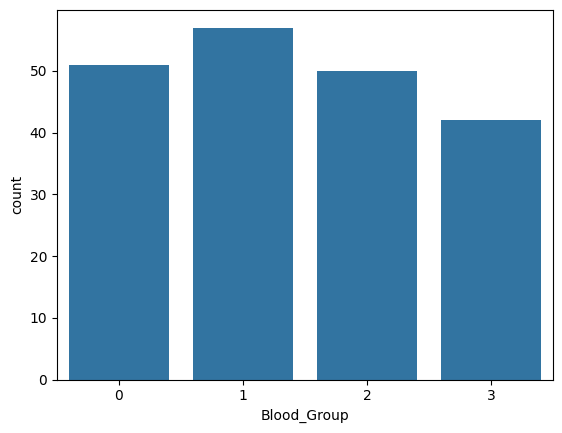

In [27]:
"""
In this step, we visualize the distribution of blood groups in the dataset.

- sns.countplot() is used to count the number of occurrences 
  of each category in the 'Blood_Group' column.

- The x-axis represents different blood groups (A, B, AB, O).
- The y-axis represents the count (number of samples).

This helps us understand how the data is distributed 
across different classes.
"""
sns.countplot(x='Blood_Group', data=data)
plt.show()